In [1]:
#import all needed libraries
import numpy as np
import pandas as pd
import itertools
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.vector_ar.var_model import VAR
import math
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
from keras.layers import *
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error
from keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras.models import Sequential
#from tensorflow.keras.layers import Dense, LSTM
import matplotlib.pyplot as plt
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

In [2]:
#read the dataset
df = pd.read_csv("amazon_sales_dataset.csv")
df.head()

,Date,Store,Dept,Unnamed: 3,Weekly_Sales,Type,Size,Temperature,Fuel_Price,CPI,...,IsHoliday,Year,Month,Week,max,min,mean,median,std,Total_MarkDown
0,05/02/2019,1,1,05/02/2019,24924.50,A,151315,42.31,2.572,211.096358,...,0,2019,2,5,57592.12,14537.37,22513.322940,18535.48,9854.349032,0.0
1,05/02/2019,9,97,05/02/2019,668.48,B,125833,38.01,2.572,214.655459,...,0,2019,2,5,766.93,-9.92,372.655556,371.05,290.954675,0.0
2,05/02/2019,9,85,05/02/2019,693.87,B,125833,38.01,2.572,214.655459,...,0,2019,2,5,2512.14,110.56,876.629441,824.04,307.436056,0.0
3,05/02/2019,8,80,05/02/2019,8654.60,A,155078,34.14,2.572,214.471451,...,0,2019,2,5,11990.43,7414.43,9188.915105,9161.97,756.223236,0.0
4,05/02/2019,9,55,05/02/2019,11123.56,B,125833,38.01,2.572,214.655459,...,0,2019,2,5,29166.26,4791.74,8607.050490,7571.60,3874.176095,0.0


In [3]:
#columns
df.columns

Index(['Date', 'Store', 'Dept', 'Unnamed: 3', 'Weekly_Sales', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday', 'Year',
       'Month', 'Week', 'max', 'min', 'mean', 'median', 'std',
       'Total_MarkDown'],
      dtype='object')

In [4]:
#Statistical description
df.describe()

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Year,Month,Week,max,min,mean,median,std,Total_MarkDown
count,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000,374247.000000
mean,22.299345,43.421369,13058.690149,134650.701571,60.241022,3.354381,173.423324,7.695551,0.061211,2019.968702,6.437807,25.788471,30520.909403,8428.549075,13346.242316,12562.757282,3592.673175,4791.216015
std,12.919329,30.087812,15417.195280,60805.893266,18.112858,0.466553,38.918398,1.390530,0.239717,0.802722,3.180864,13.840661,42046.263020,11364.174300,15474.285934,15032.726407,5243.661887,8782.811084
min,1.000000,1.000000,0.000000,34875.000000,14.020000,2.472000,126.064000,3.879000,0.000000,2019.000000,1.000000,1.000000,0.020000,-4988.940000,-116.454545,-143.000000,0.000000,0.000000
25%,11.000000,18.000000,1979.800000,93188.000000,47.130000,2.891000,132.756800,6.858000,0.000000,2019.000000,4.000000,14.000000,5794.330000,675.000000,2308.411818,2017.000000,731.571412,0.000000
50%,22.000000,36.000000,7101.310000,128107.000000,62.490000,3.462000,188.797935,7.838000,0.000000,2020.000000,6.000000,26.000000,17294.460000,3847.950000,7534.953916,6856.100000,1880.958217,0.000000
75%,33.000000,72.000000,18252.355000,202307.000000,74.220000,3.738000,213.178695,8.512000,0.000000,2021.000000,9.000000,37.000000,41082.450000,11424.500000,18687.708250,17317.790000,4263.309723,6893.330000
max,45.000000,99.000000,72756.180000,219622.000000,100.140000,4.468000,227.232807,12.187000,1.000000,2021.000000,12.000000,52.000000,649770.180000,72028.740000,108598.364100,107690.800000,71265.927070,43413.900000


In [5]:
#Checking null values
df.isnull().sum()

Date              0
Store             0
Dept              0
Unnamed: 3        0
Weekly_Sales      0
Type              0
Size              0
Temperature       0
Fuel_Price        0
CPI               0
Unemployment      0
IsHoliday         0
Year              0
Month             0
Week              0
max               0
min               0
mean              0
median            0
std               0
Total_MarkDown    0
dtype: int64

In [6]:
#shape of dataset
df.shape

(374247, 21)

In [7]:
#convert date to date time
df['Date'] = pd.to_datetime(df['Date'])
df_monthly = df.groupby(pd.Grouper(key='Date', freq='M')).agg({'Weekly_Sales': 'sum'}).reset_index()


In [8]:
#added 3 new columns - year, month, quarter
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Season'] = df['Date'].dt.quarter


In [9]:
#minimum 
df['Date'].min()

Timestamp('2019-01-10 00:00:00')

In [10]:
#maximum
df['Date'].max()

Timestamp('2021-12-10 00:00:00')

In [11]:
#date and weeksales dataset
df = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

In [12]:
#first 5 rows of dataset
df.head()

,Date,Weekly_Sales
0,2019-01-10,33163834.91
1,2019-02-04,36690313.80
2,2019-02-07,36428077.88
3,2019-02-19,35401134.48
4,2019-02-26,32932160.46


In [13]:
# datae column as index
df = df.set_index('Date')
df.index

DatetimeIndex(['2019-01-10', '2019-02-04', '2019-02-07', '2019-02-19',
               '2019-02-26', '2019-03-09', '2019-03-12', '2019-03-19',
               '2019-03-26', '2019-04-06',
               ...
               '2021-09-03', '2021-09-14', '2021-09-21', '2021-09-28',
               '2021-10-02', '2021-10-08', '2021-10-19', '2021-10-26',
               '2021-11-05', '2021-12-10'],
              dtype='datetime64[ns]', name='Date', length=143, freq=None)

In [14]:
#first 5 rows of dataset
df.head()

,Weekly_Sales
Date,
2019-01-10,33163834.91
2019-02-04,36690313.80
2019-02-07,36428077.88
2019-02-19,35401134.48
2019-02-26,32932160.46


In [15]:
#y
y = df['Weekly_Sales'].resample('MS').mean()

In [16]:
#2021
y['2021':]

Date
2021-01-01    3.411764e+07
2021-02-01    2.795289e+07
2021-03-01    2.669077e+07
2021-04-01    3.637755e+07
2021-05-01    3.757305e+07
2021-06-01    3.511878e+07
2021-07-01    3.617736e+07
2021-08-01    3.694799e+07
2021-09-01    3.545179e+07
2021-10-01    3.455386e+07
2021-11-01    3.775585e+07
2021-12-01    3.688105e+07
Freq: MS, Name: Weekly_Sales, dtype: float64

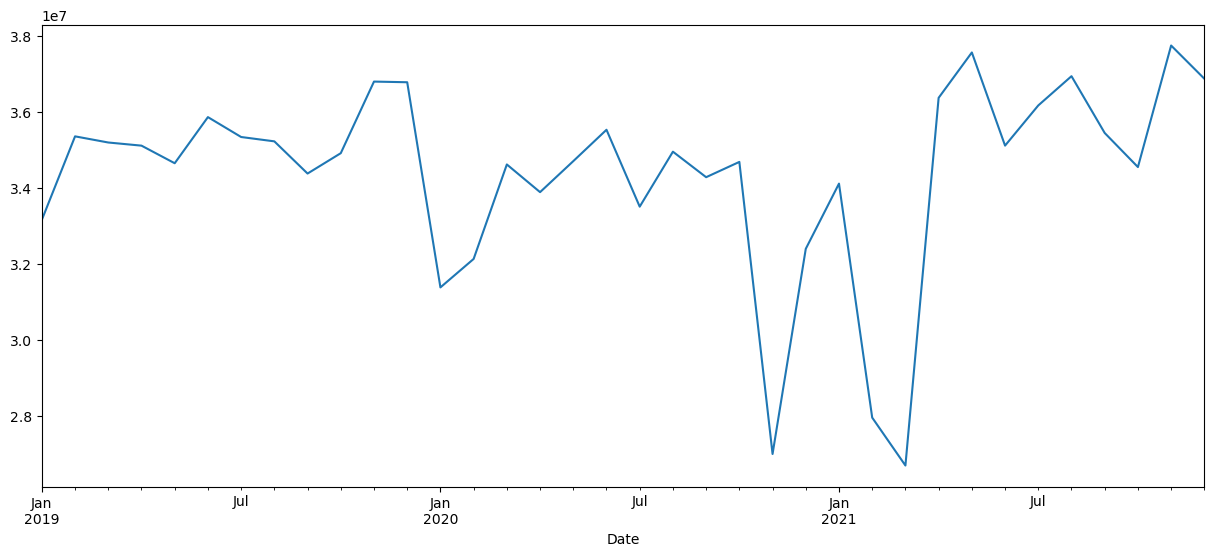

In [17]:
#plot for y - sales trend over the specific years, it's sales pattern
y.plot(figsize=(15, 6))
plt.show()

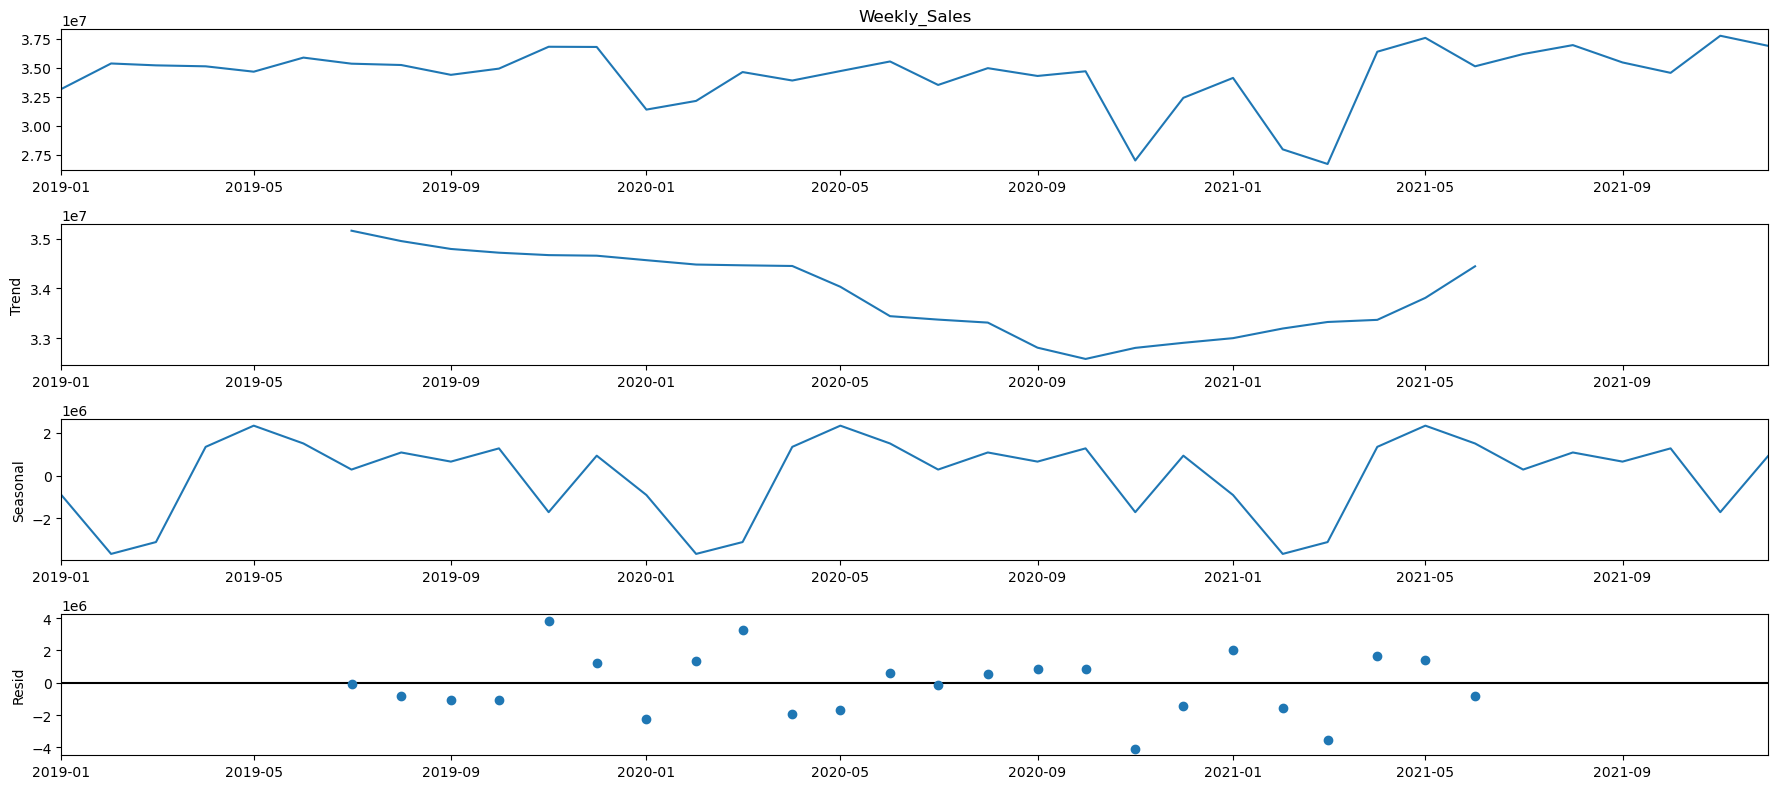

In [18]:
#trend , resid and seasonal plot - it identifies patterns, irregularities, and fluctuations within the dataset
from pylab import rcParams
rcParams['figure.figsize'] = 18, 8

decomposition = sm.tsa.seasonal_decompose(y, model='additive')
fig = decomposition.plot()
plt.show()

### ARIMA

In [19]:
#seasonal ARIMA
p = d = q = range(0, 2) #parameters
pdq = list(itertools.product(p, d, q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))] #created tuple

print('parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)


In [20]:
#AIC result - AIC is a metric used to compare different models.
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(y,
                                            order=param,
                                            seasonal_order=param_seasonal,
                                            enforce_stationarity=False,
                                            enforce_invertibility=False)

            results = mod.fit()

            print('ARIMA{}x{}12 - AIC:{}'.format(param, param_seasonal, results.aic))
        except:
            continue

ARIMA(0, 0, 0)x(0, 0, 0, 12)12 - AIC:1316.2984445182497
ARIMA(0, 0, 0)x(0, 0, 1, 12)12 - AIC:2307.07000825393
ARIMA(0, 0, 0)x(0, 1, 0, 12)12 - AIC:770.0104269806259
ARIMA(0, 0, 0)x(0, 1, 1, 12)12 - AIC:373.2802868671975
ARIMA(0, 0, 0)x(1, 0, 0, 12)12 - AIC:801.5573166244596
ARIMA(0, 0, 0)x(1, 0, 1, 12)12 - AIC:773.3629443985039
ARIMA(0, 0, 0)x(1, 1, 0, 12)12 - AIC:399.38027965950687
ARIMA(0, 0, 0)x(1, 1, 1, 12)12 - AIC:369.16672828625826
ARIMA(0, 0, 1)x(0, 0, 0, 12)12 - AIC:1257.158712796754
ARIMA(0, 0, 1)x(0, 0, 1, 12)12 - AIC:812.9073607261274
ARIMA(0, 0, 1)x(0, 1, 0, 12)12 - AIC:733.6721090450925
ARIMA(0, 0, 1)x(0, 1, 1, 12)12 - AIC:339.35081015463066
ARIMA(0, 0, 1)x(1, 0, 0, 12)12 - AIC:883.3742246598141
ARIMA(0, 0, 1)x(1, 0, 1, 12)12 - AIC:812.1983240658803
ARIMA(0, 0, 1)x(1, 1, 0, 12)12 - AIC:400.87139237022194
ARIMA(0, 0, 1)x(1, 1, 1, 12)12 - AIC:334.64950925635355
ARIMA(0, 1, 0)x(0, 0, 0, 12)12 - AIC:1111.9225238067243
ARIMA(0, 1, 0)x(0, 0, 1, 12)12 - AIC:725.3560978235168
ARIM

In [21]:
# Fit the ARIMA(1, 1, 1)x(1, 1, 1, 12)12 model
mod = sm.tsa.statespace.SARIMAX(y,
                                order=(1, 1, 1),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
results = mod.fit()

# Print the summary table
print(results.summary().tables[1])

# 2.135e+13 - indicate issues with model fit or scaling in your data.

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0090      6.610      0.001      0.999     -12.946      12.964
ma.L1         -0.6525      1.166     -0.560      0.576      -2.937       1.632
ar.S.L12      -0.2929     28.519     -0.010      0.992     -56.189      55.604
ma.S.L12      -0.9815     11.850     -0.083      0.934     -24.207      22.244
sigma2      2.135e+13   1.01e-13   2.12e+26      0.000    2.14e+13    2.14e+13


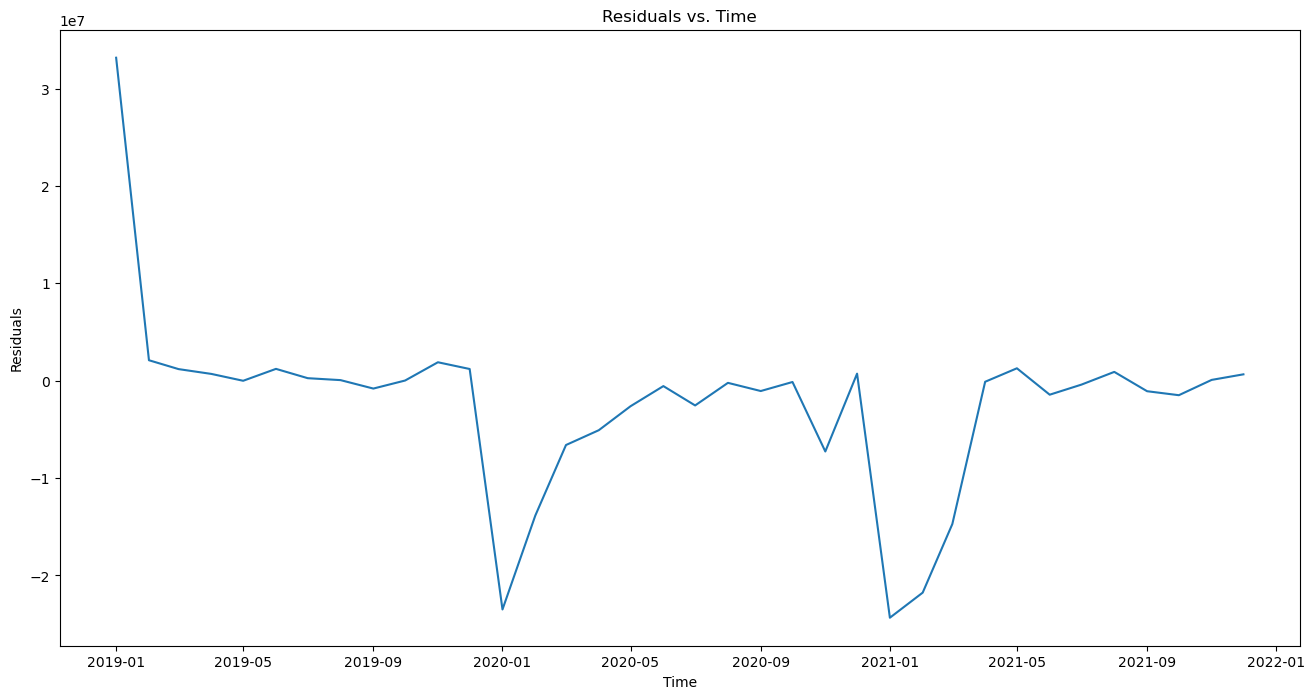

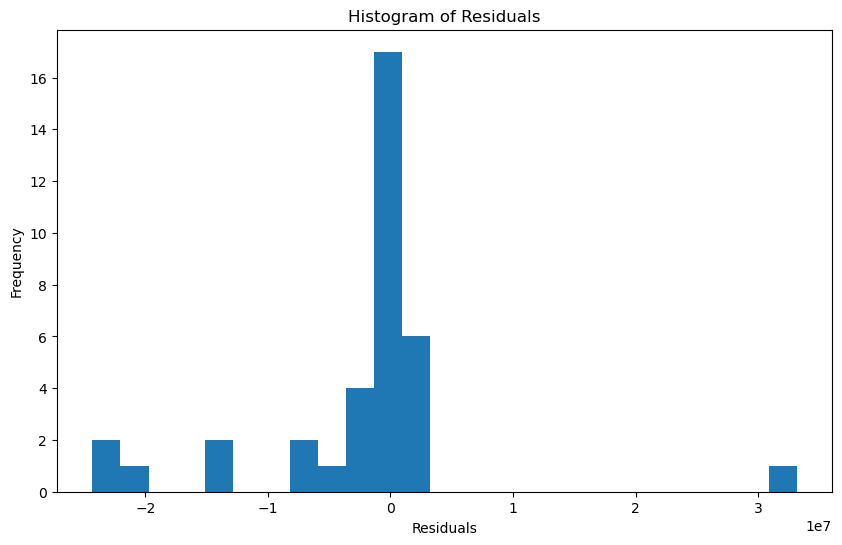

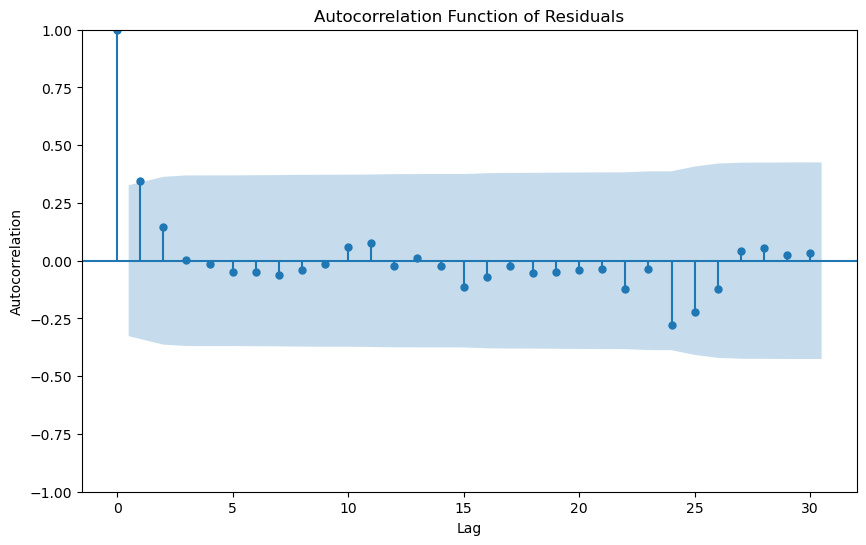

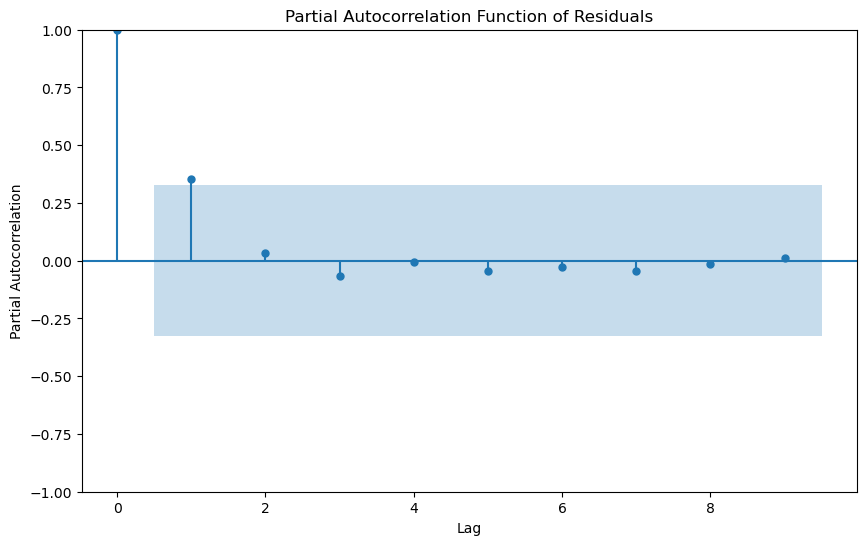

In [22]:
# Plot the residuals vs. time - it serves to examine the distribution of residuals across time intervals
fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(y.index, results.resid)
ax.set_xlabel('Time')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs. Time')

# Plot the histogram of residuals - it comprehending the frequency distribution of the residuals
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(results.resid, bins=25)
ax.set_xlabel('Residuals')
ax.set_ylabel('Frequency')
ax.set_title('Histogram of Residuals')

# Plot the autocorrelation function (ACF) of residuals - This plot gauges the correlation between residuals at varying time lags
fig, ax = plt.subplots(figsize=(10, 6))
sm.graphics.tsa.plot_acf(results.resid, lags=30, ax=ax)
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation Function of Residuals')

# Plot the partial autocorrelation function (PACF) of residuals - plot highlights the correlation between residuals at various lags 
# while considering the influence of intermediate lags
fig, ax = plt.subplots(figsize=(10, 6))
sm.graphics.tsa.plot_pacf(results.resid, lags=9, ax=ax)
ax.set_xlabel('Lag')
ax.set_ylabel('Partial Autocorrelation')
ax.set_title('Partial Autocorrelation Function of Residuals')
plt.show()


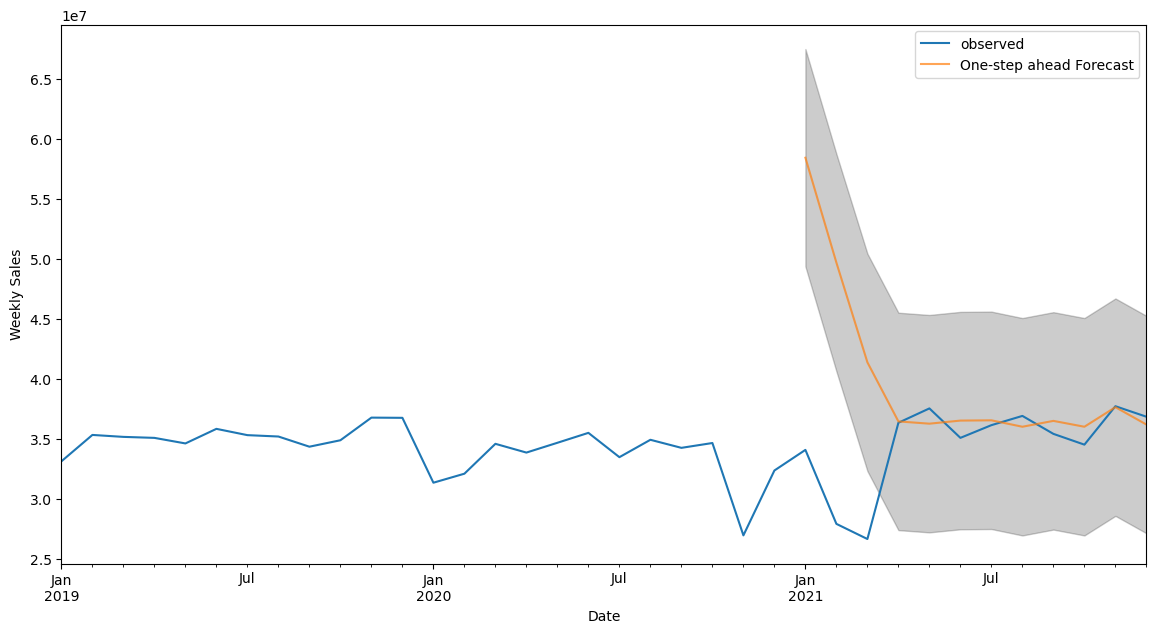

In [23]:
# weekly sales prediction for 2019-2021
pred = results.get_prediction(start=pd.to_datetime('2021-01-01'), dynamic=False)
pred_ci = pred.conf_int()

ax = y['2019':].plot(label='observed')
pred.predicted_mean.plot(ax=ax, label='One-step ahead Forecast', alpha=.7, figsize=(14, 7))

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.2)

ax.set_xlabel('Date')
ax.set_ylabel('Weekly Sales')
plt.legend()

plt.show()

In [24]:
#MSE(Mean Squared Error) - MSE measures the average squared difference between the predicted and actual values.
#Lower MSE is better fit
y_forecasted = pred.predicted_mean
y_truth = y['2021-01-01':]

# Compute the mean square error
mse = ((y_forecasted - y_truth) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 2)))

The Mean Squared Error of our forecasts is 107623430346009.94


In [25]:
#RMSE - It is the square root of the MSE, and it provides a clearer sense of the average 
# magnitude of the prediction errors in the original units of the target variable.

print('The Root Mean Squared Error of our forecasts is {}'.format(round(np.sqrt(mse), 2)))

# Calculate MAPE(Mean Absolute % Error) - MAPE calculates the percentage difference between the predicted and actual values, 
# and then takes the average of these percentage errors. 
mape = np.mean(np.abs((y_forecasted - y_truth) / y_truth)) * 100

# Print the MAPE
print('The Mean Absolute Percentage Error (MAPE) of our forecasts is {:.2f}%'.format(mape))


The Root Mean Squared Error of our forecasts is 10374171.31
The Mean Absolute Percentage Error (MAPE) of our forecasts is 18.76%


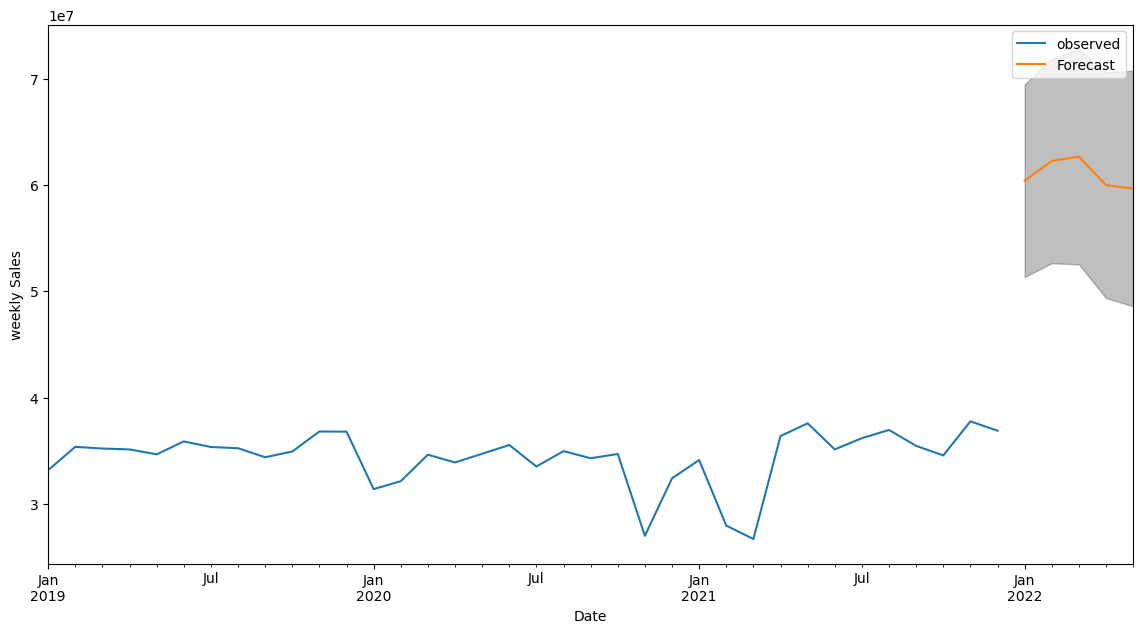

In [26]:
#Forecast
pred_uc = results.get_forecast(steps=5)
pred_ci = pred_uc.conf_int() #this function gives the prediction level

ax = y.plot(label='observed', figsize=(14, 7))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)
ax.set_xlabel('Date')
ax.set_ylabel('weekly Sales')

plt.legend()
plt.show()

In [27]:
# used to generate forecasts and their intervals using time series model (SARIMA model)
# Generate predictions for the next 5 time steps
forecast_steps = 5
forecast = results.get_forecast(steps=forecast_steps)

# Extract the forecasted values and confidence intervals
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

# Print the forecasted values
print("Forecasted Values:")
print(forecast_mean)

# Print the confidence intervals
print("\nConfidence Intervals:")
print(forecast_conf_int)

Forecasted Values:
2022-01-01    6.039765e+07
2022-02-01    6.224843e+07
2022-03-01    6.265054e+07
2022-04-01    5.997332e+07
2022-05-01    5.965380e+07
Freq: MS, Name: predicted_mean, dtype: float64

Confidence Intervals:
            lower Weekly_Sales  upper Weekly_Sales
2022-01-01        5.134064e+07        6.945466e+07
2022-02-01        5.263291e+07        7.186395e+07
2022-03-01        5.252384e+07        7.277724e+07
2022-04-01        4.936016e+07        7.058647e+07
2022-05-01        4.857553e+07        7.073206e+07


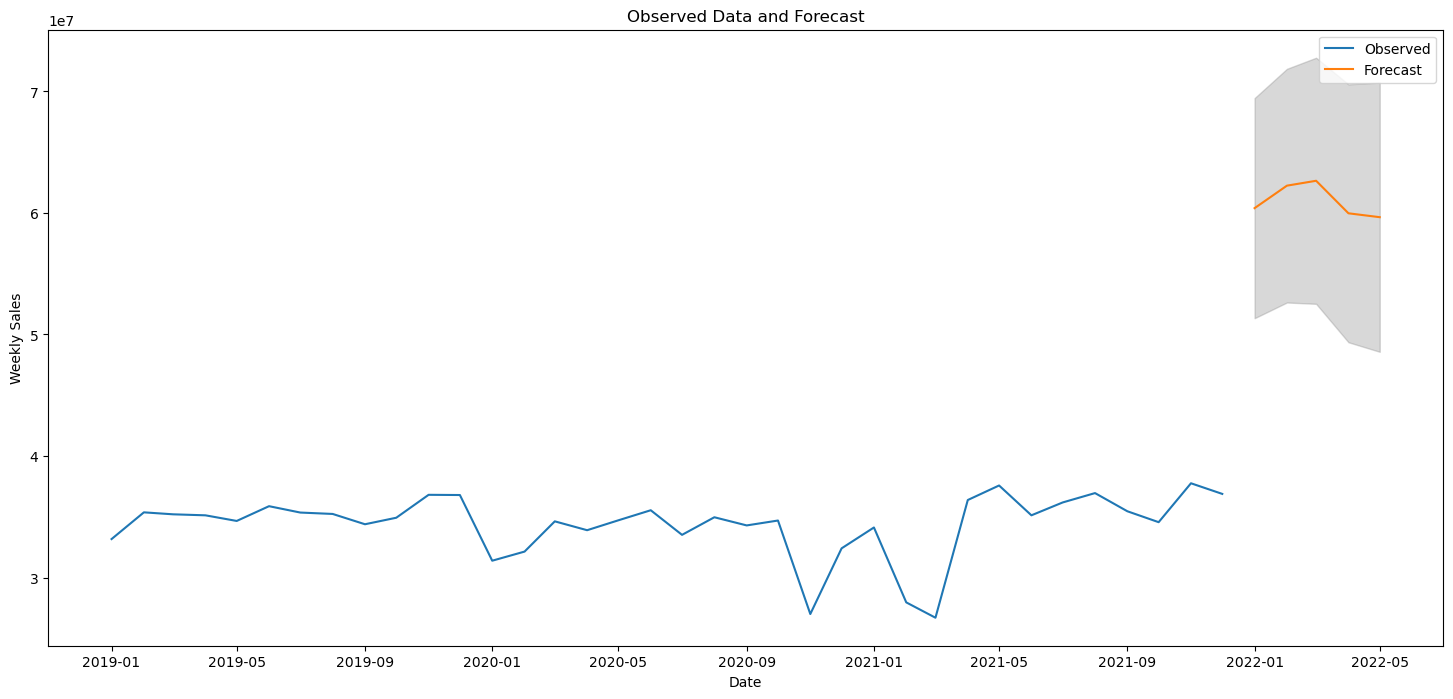

In [28]:
#This visualization helps stakeholders understand the accuracy and reliability 
# of the forecasted sales values and make informed decisions based on this information

# Plot the observed data
plt.plot(y.index, y, label='Observed')

# Plot the forecasted values
plt.plot(forecast_mean.index, forecast_mean, label='Forecast')

# Fill the confidence interval area
plt.fill_between(forecast_conf_int.index, forecast_conf_int['lower Weekly_Sales'], forecast_conf_int['upper Weekly_Sales'], color='gray', alpha=0.3)

# Set plot labels and title
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Observed Data and Forecast')

# Display legend
plt.legend()

# Show the plot
plt.show()


In [29]:
# Reshape the dataset
dataset = df.Weekly_Sales.values.astype('float32')
dataset = np.reshape(dataset, (-1, 1))

#It help to balance the impact of all variables on the distance calculation and can help to improve the performance of the algorithm
# Scale the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

# Split the dataset into train and test - 80% training and 20% test data
train_size = int(len(dataset) * 0.80)
train, test = dataset[0:train_size, :], dataset[train_size:len(dataset), :]

# Create input-output pairs
def create_dataset(dataset, look_back=1): #defines how many previous timesteps are used in order to predict the subsequent timestep
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        X.append(a)
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Define the look_back parameter
look_back = 28  #to control the length of the input sequence of past data points that the model while making predictions 

# Create the training dataset
X_train, Y_train = create_dataset(train, look_back)

# Create the test dataset
X_test, Y_test = create_dataset(test, look_back)

# Reshape the input datasets to [samples, time steps, features] -  to improve model performance
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Print the shapes of the datasets
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape) #corresponding labels
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape) #single target variable



X_train shape: (86, 28, 1)
Y_train shape: (86,)
X_test shape: (1, 28, 1)
Y_test shape: (1,)


In [30]:
# Create a new dataframe with only the 'weekly sales column  - used to filter a dataframe based on the column names, rather than the column values
data = df.filter(['Weekly_Sales'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))

training_data_len

136

In [31]:
# Scale the data -  to normalize continuous numerical data
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.71677461],
       [0.80577185],
       [0.79915384],
       [0.77323702],
       [0.71092788],
       [0.75407388],
       [0.80721363],
       [0.76216908],
       [0.7492709 ],
       [0.83736777],
       [0.74071405],
       [0.74802606],
       [0.73826362],
       [0.71236477],
       [0.73147908],
       [0.75985112],
       [0.75816345],
       [0.75686849],
       [0.80765421],
       [0.78313947],
       [0.78211516],
       [0.78993872],
       [0.78699685],
       [0.77732355],
       [0.76318965],
       [0.75983567],
       [0.74041613],
       [0.77190766],
       [0.78673686],
       [0.77673037],
       [0.79099784],
       [0.78408853],
       [0.70872393],
       [0.70635639],
       [0.74235396],
       [0.86254914],
       [0.7231558 ],
       [0.73361066],
       [0.74375891],
       [0.78377778],
       [0.75695827],
       [0.88532145],
       [0.77008407],
       [0.73376449],
       [0.75239359],
       [0.90717684],
       [1.        ],
       [0.686

In [32]:
# Create the training data set 
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()
        
# Convert the x_train and y_train to numpy arrays 
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

[array([0.71677461, 0.80577185, 0.79915384, 0.77323702, 0.71092788,
       0.75407388, 0.80721363, 0.76216908, 0.7492709 , 0.83736777,
       0.74071405, 0.74802606, 0.73826362, 0.71236477, 0.73147908,
       0.75985112, 0.75816345, 0.75686849, 0.80765421, 0.78313947,
       0.78211516, 0.78993872, 0.78699685, 0.77732355, 0.76318965,
       0.75983567, 0.74041613, 0.77190766, 0.78673686, 0.77673037,
       0.79099784, 0.78408853, 0.70872393, 0.70635639, 0.74235396,
       0.86254914, 0.7231558 , 0.73361066, 0.74375891, 0.78377778,
       0.75695827, 0.88532145, 0.77008407, 0.73376449, 0.75239359,
       0.90717684, 1.        , 0.68604296, 0.71440933, 0.79311625,
       0.63600184, 0.64636631, 0.56931741, 0.72215805, 0.5539633 ,
       0.7761551 , 0.71080128, 0.80619245, 0.73674544, 0.71781016])]
[0.6302654529243583]

[array([0.71677461, 0.80577185, 0.79915384, 0.77323702, 0.71092788,
       0.75407388, 0.80721363, 0.76216908, 0.7492709 , 0.83736777,
       0.74071405, 0.74802606, 0.738

### LSTM

In [33]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model using keras
model = Sequential() #To train a deep neural network to classify sequential data
#return_sequence - Whether to return the last output in the output sequence, or the full sequence, bydefault = falses
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1))) #return a sequence of vector dimesnion 128
model.add(LSTM(64, return_sequences=False)) #return a sequence of vector dimesnion 64
model.add(Dense(25)) #return a single vector dimesnion 25
model.add(Dense(1)) #return a single vector dimesnion 1 

# Compile the model - judge the performance of model
model.compile(optimizer='adam', loss='mean_squared_error')
#Adam - helps improve the accuracy of neural networks by adjusting the model's learnable parameters.

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

76/76 [==============================] - 16s 60ms/step - loss: 0.0575


In [34]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002 
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array - Numpy arrays are more compact than python lists, which uses less memory.
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

1/1 [==============================] - 3s 3s/step


4361673.241805097

In [35]:
# Calculate Mean Squared Error (MSE)
mse = np.mean((predictions - y_test) ** 2)
print('MSE:',mse)
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
print('Mape:',mape)

MSE: 19024193468278.586
Mape: 8.352253437350317


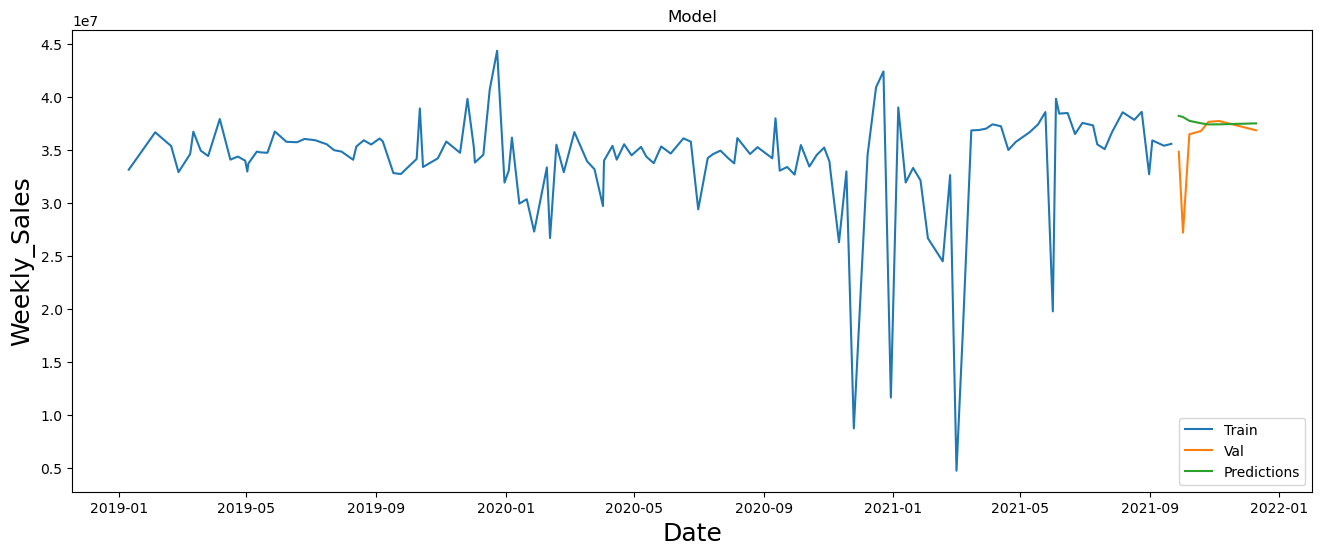

In [36]:
#The plot provides a clear representation of the model's effectiveness 
#in predicting weekly sales and allows stakeholders to make informed decisions based on the model's performance.
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Weekly_Sales', fontsize=18)
plt.plot(train['Weekly_Sales'])
plt.plot(valid[['Weekly_Sales', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [37]:
#Valid
valid

,Weekly_Sales,Predictions
Date,,
2021-09-28,34857936.64,38239528.0
2021-10-02,27222620.20,38132364.0
2021-10-08,36508857.43,37771232.0
2021-10-19,36809629.85,37542524.0
2021-10-26,37674329.61,37432916.0
2021-11-05,37755847.82,37440540.0
2021-12-10,36881054.55,37531640.0


### Attention Mechanism

In [38]:
#It gives attention to particular variables, it improves prediction accuracy and computational efficiency by prioritizing the informations.
from keras.models import Model
from keras.layers import Input, Dense, LSTM, Lambda, concatenate
# Build the attention model
input = Input(shape=(x_train.shape[1], 1))
lstm = LSTM(128, return_sequences=True)(input) #it improves model performance by focusing on relavent information
#Tanh - is a mathematical function commonly used in artificial neural networks for their hidden layers. 
attention = Dense(1, activation='tanh')(lstm) #it calculates attention wieghts
attention = Lambda(lambda x: keras.backend.squeeze(keras.backend.softmax(x, axis=1), axis=-1))(attention) #to computer attention wt foe each axis to get 1-dimensional
attention = keras.backend.repeat_elements(attention, 128, axis=1)

import keras

# Reshape attention tensor
attention = keras.layers.Reshape((60, 128))(attention) #to ensure compatability with other parts of network architecture and it changes 
#shape to 60 rows & 128 col

# Perform element-wise multiplication - llowing the model to focus on relevant parts of the input data, 
# which is crucial for tasks like sequence-to-sequence processing and natural language understanding.
weighted_input = keras.layers.Multiply()([lstm, attention])

output = keras.layers.GlobalAveragePooling1D()(weighted_input) #which can be useful for reducing the dimensionality of the data and preparing it for final output or classification.
output = Dense(25, activation='relu')(output) #introduces non-linearity to the model and can help in learning complex patterns in the data
output = Dense(1)(output) #to produce a single numeric output value, which could represent a prediction

model = Model(inputs=input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

# Get the model's predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Calculate the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))



1/1 [==============================] - 4s 4s/step


In [39]:
# Calculate Mean Squared Error (MSE)
mse = np.mean((predictions - y_test) ** 2)
print('MSE:',mse)
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
print('Mape:',mape)

MSE: 95029388871372.2
Mape: 24.898901076861918


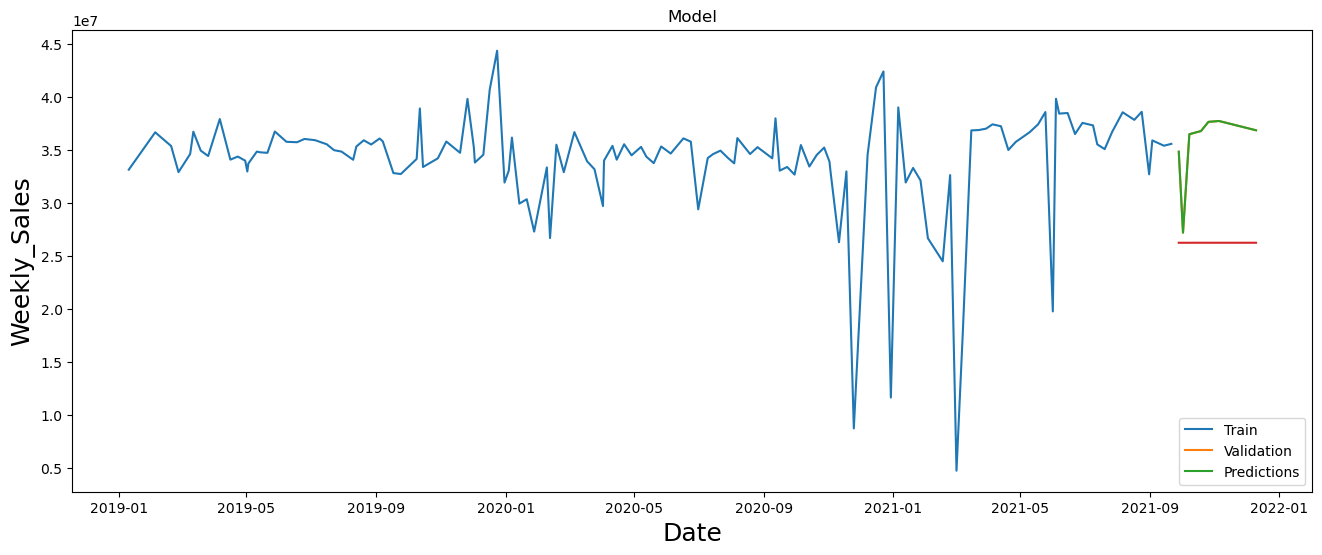

In [40]:
# Create a new DataFrame for predictions
pred_data = data[training_data_len:].copy()
pred_data['Predictions'] = predictions[:len(valid)]  # Adjust the length of predictions to match valid

# Visualize the data
plt.figure(figsize=(16, 6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Weekly_Sales', fontsize=18)
plt.plot(train['Weekly_Sales'])
plt.plot(valid['Weekly_Sales'])
plt.plot(pred_data[['Weekly_Sales', 'Predictions']])
plt.legend(['Train', 'Validation', 'Predictions'], loc='lower right')
plt.show()

### GNN

In [87]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import numpy as np

# x_train and y_train are your training data and labels
x_train = scaled_data[60:]  # Shape: (num_samples, num_features)
y_train = scaled_data[60:, 0]  # target variable is in the first column

# Convert the numpy arrays to torch tensors - seamless integration with PyTorch models, and utilizing PyTorch's automatic differentiation and broader ecosystem
x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train).float()

# Define the edge index (as a directed graph) - creates a tensor representing edge connections between nodes in a graph
edge_index = torch.tensor([[i, i+1] for i in range(x_train.shape[0] - 1)], dtype=torch.long).t().contiguous()

# Create the graph data
data = Data(x=x_train, edge_index=edge_index, y=y_train)

# Define the GNN model
class GNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim): #set up initial attributes and configurations for objects created from this class.
        super(GNN, self).__init__() #used to call the constructor of the parent class nn.Module and 
        self.conv1 = GCNConv(input_dim, hidden_dim) #defining a layer for processing graph-structured data in the neural network for input
        self.conv2 = GCNConv(hidden_dim, output_dim) #for output

    def forward(self, x, edge_index): #pass through the GNN model's layers and modules to produce the model's output
        x = self.conv1(x, edge_index) #performing a graph convolution operation on the data.
        x = F.relu(x) #Rectified Linear Unit (ReLU) function introducing non-linearity to the data by replacing negative values with zeros.
        x = self.conv2(x, edge_index) #performing another graph convolution operation on the data, potentially in a deeper layer of the neural network
        return x #returns output of the model

# Define the model
input_dim = x_train.shape[1] #represents the input
hidden_dim = 16 #smaller value can lead to a more compact and computationally efficient model
output_dim = 1 #set to 1 because the objective is to predict a continuous numeric value
model = GNN(input_dim, hidden_dim, output_dim) # allowing you to use this model for training and making predictions on your data

# Define the optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) #controlling the step size in the parameter updates
criterion = nn.MSELoss()

# Training loop
model.train() #starting of training loop
for epoch in range(100):  #used to iterate through 100 training epochs, allowing the model to learn from the training data in multiple passes to improve performance
    optimizer.zero_grad() #ensuring that the gradients are fresh and do not accumulate from previous iterations
    output = model(data.x, data.edge_index) #predictions or representations learned by the model
    loss = criterion(output, data.y.view(-1, 1)) #computes the loss by applying the previously defined Mean Squared Error (MSE) loss function
    loss.backward()
    optimizer.step() # adjust the model's weights and biases in the direction that reduces the loss, allowing the model to learn from the training data

# Set the model to evaluation mode
model.eval() #ensuring it behaves consistently during inference and testing

# Generate predictions
with torch.no_grad():
    predictions = model(data.x, data.edge_index)

# Denormalize the predictions - to convert the model's output from a scaled or transformed representation back to the original data domain, 
# ensuring meaningful and interpretable results
predictions = (predictions * y_train.std()) + y_train.mean()
y_train = (y_train * y_train.std()) + y_train.mean()

# Calculate MSE
mse = criterion(predictions, y_train.view(-1, 1))
# Calculate RMSE
rmse = torch.sqrt(mse)

# Calculate MAPE
ape = torch.abs((y_train - predictions) / torch.clamp(torch.abs(y_train), min=1e-7))
mape = torch.mean(ape) * 100

print("MSE:", mse.item())
print("RMSE:", rmse.item())
print("MAPE:", mape.item())


MSE: 0.00048008031444624066
RMSE: 0.021910734474658966
MAPE: 2.111924886703491


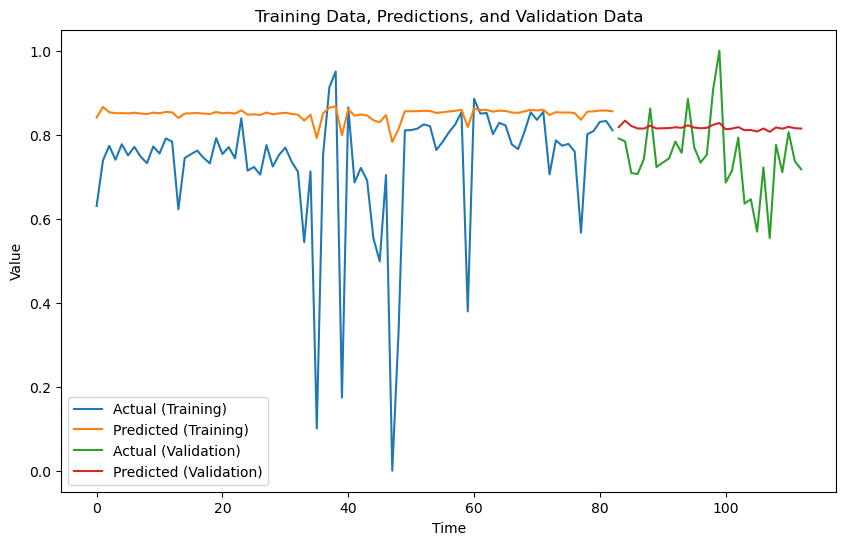

In [88]:
# Split the dataset into training, validation, and forecast data preventing overfitting to the training data and ensuring its ability to generalize to unseen data
x_train = scaled_data[60:] #starting from the 60th index  
y_train = scaled_data[60:, 0]  # target variable is in the first column
x_valid = scaled_data[30:60]  # Shape: (num_samples, num_features)
y_valid = scaled_data[30:60, 0]  # target variable is in the first column
x_forecast = scaled_data[:30]  # Shape: (num_samples, num_features)

# Convert the numpy arrays to torch tensors
x_train = torch.from_numpy(x_train).float()
y_train = torch.from_numpy(y_train).float()
x_valid = torch.from_numpy(x_valid).float()
y_valid = torch.from_numpy(y_valid).float()
x_forecast = torch.from_numpy(x_forecast).float()

# Define the edge index (as a directed graph)
edge_index = torch.tensor([[0, 1, 2, 3, 4], [1, 2, 3, 4, 4]], dtype=torch.long) #1st row source node and 2nd row destination node

# Create the graph data for training and validation
train_data = Data(x=x_train, edge_index=edge_index, y=y_train)
valid_data = Data(x=x_valid, edge_index=edge_index, y=y_valid)

# Define the model
input_dim = 1 #one feature selected
hidden_dim = 16
output_dim = 1
model = GNN(input_dim, hidden_dim, output_dim)

# Define the optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Training loop
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    output = model(train_data.x, train_data.edge_index)
    loss = criterion(output, train_data.y.view(-1, 1))
    loss.backward()
    optimizer.step()

# Set the model to evaluation mode
model.eval()

# Generate predictions for training and validation data
with torch.no_grad():
    train_predictions = model(train_data.x, train_data.edge_index)
    valid_predictions = model(valid_data.x, valid_data.edge_index)

# Denormalize the predictions
train_predictions = (train_predictions * y_train.std()) + y_train.mean()
valid_predictions = (valid_predictions * y_valid.std()) + y_valid.mean()

# Plotting
plt.figure(figsize=(10, 6))

# Plot training data
plt.plot(range(len(y_train)), y_train, label='Actual (Training)')
plt.plot(range(len(y_train)), train_predictions, label='Predicted (Training)')

# Plot validation data
plt.plot(range(len(y_train), len(y_train) + len(y_valid)), y_valid, label='Actual (Validation)')
plt.plot(range(len(y_train), len(y_train) + len(y_valid)), valid_predictions, label='Predicted (Validation)')

plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Training Data, Predictions, and Validation Data')
plt.legend()
plt.show()


### RNN

In [41]:
model = Sequential()
model.add(SimpleRNN(128, input_shape=(x_train.shape[1], 1), activation='relu')) #chose 128 for avoiding excessive computational complexity and overfitting
model.add(Dense(25, activation='relu')) # increases the model's expressive power by transforming the previous layer's output into a higher-dimensional representation
model.add(Dense(1)) #to predict a continuous numeric value as the final output as single continous numeric value

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error') # MSE-difference between predicted and actual values

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

76/76 [==============================] - 5s 21ms/step - loss: 0.0540


In [42]:
# Get the model's predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Calculate the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))

1/1 [==============================] - 0s 484ms/step


In [43]:
rmse

4574596.377325887

In [44]:
# Calculate Mean Squared Error (MSE)
mse = np.mean((predictions - y_test) ** 2)
print('MSE:',mse)
# Calculate Mean Absolute Percentage Error (MAPE)
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
print('Mape:',mape)

MSE: 20926932015443.13
Mape: 12.39386597001567


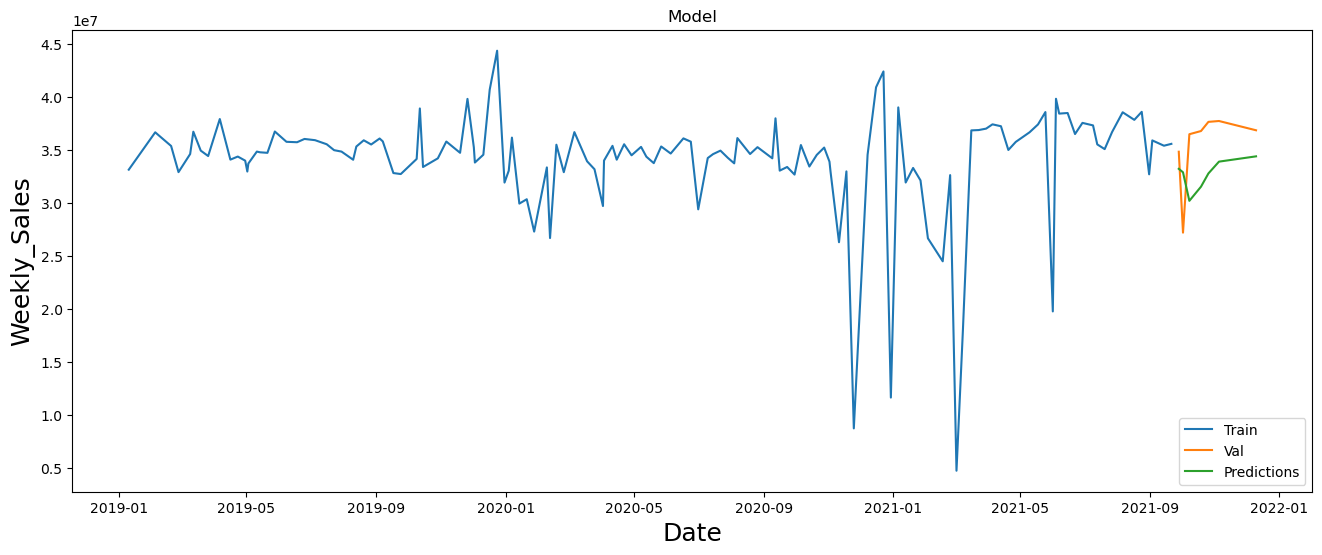

In [45]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Weekly_Sales', fontsize=18)
plt.plot(train['Weekly_Sales'])
plt.plot(valid[['Weekly_Sales', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

### VAR

In [46]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import MinMaxScaler

# Assuming you have the 'Weekly_Sales' column as a pandas Series named 'data'
data = df['Weekly_Sales']

# Convert the data to a numpy array
dataset = data.values

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(dataset.reshape(-1, 1))

# Define the training data length
training_data_len = int(np.ceil(len(dataset) * 0.95)) #rest 0.05% as testing purpose

# Create the training data set
train_data = scaled_data[:training_data_len]

# Create the testing data set
test_data = scaled_data[training_data_len:]

# Define the lag order for VAR
lag_order = 3  #  may be meaningful relationships and dependencies between the variables within this three-time-step window, 
               #allowing the model to capture and predict complex interactions in the data.

# Create lagged variables for VAR model
train_data_lagged = pd.DataFrame(train_data, columns=['Weekly_Sales']) #creates a new data framce and useful when you want to focus on or manipulate a specific column of your dataset for further analysis or modeling.
for i in range(1, lag_order + 1): #process and analyze data with respect to a specified number of past time steps or lags in time series analysis
    train_data_lagged[f'Lag_{i}'] = train_data_lagged['Weekly_Sales'].shift(i)

# Remove the rows with NaN values
train_data_lagged = train_data_lagged.dropna() #remvoes rows with missing values (NaN) from the 'train_data_lagged' DataFrame

# Fit the VAR model
model = VAR(train_data_lagged)
results = model.fit(maxlags=lag_order, ic='aic') #uses (AIC) to determine the optimal lag order, aiming to find the best-fitting VAR model for the data.

# Get the lagged variables for the testing data set
test_data_lagged = pd.DataFrame(test_data, columns=['Weekly_Sales'])
for i in range(1, lag_order + 1):
    test_data_lagged[f'Lag_{i}'] = test_data_lagged['Weekly_Sales'].shift(i)

# Remove the rows with NaN values
test_data_lagged = test_data_lagged.dropna()

# Get the lagged variables for the last 'lag_order' training data points
last_train_data = train_data_lagged.tail(1).values.reshape(1, -1) #done to prepare a single data point for prediction 

# Forecast using the VAR model
predictions = results.forecast(last_train_data, len(test_data_lagged)) #where you want to predict future values based on historical data and the model's learned patterns

# Inverse scale the predictions
predictions = scaler.inverse_transform(predictions)[:, 0] #focusing on the first column of the predictions

# Inverse scale the actual values for comparison
y_test = scaler.inverse_transform(test_data_lagged)[:, 0] #done to obtain the actual values in the original data domain for comparison with model predictions 

# Calculate RMSE
rmse = np.sqrt(np.mean((predictions - y_test) ** 2))
print("RMSE:", rmse)


RMSE: 2943177.6100172307


In [47]:
# Calculate MAPE
mape = np.mean(np.abs((predictions - y_test) / y_test)) * 100
print("MAPE:", mape)

# Calculate MSE
mse = np.mean((predictions - y_test) ** 2)
print("MSE:", mse)


MAPE: 7.827096166688452
MSE: 8662294444106.739


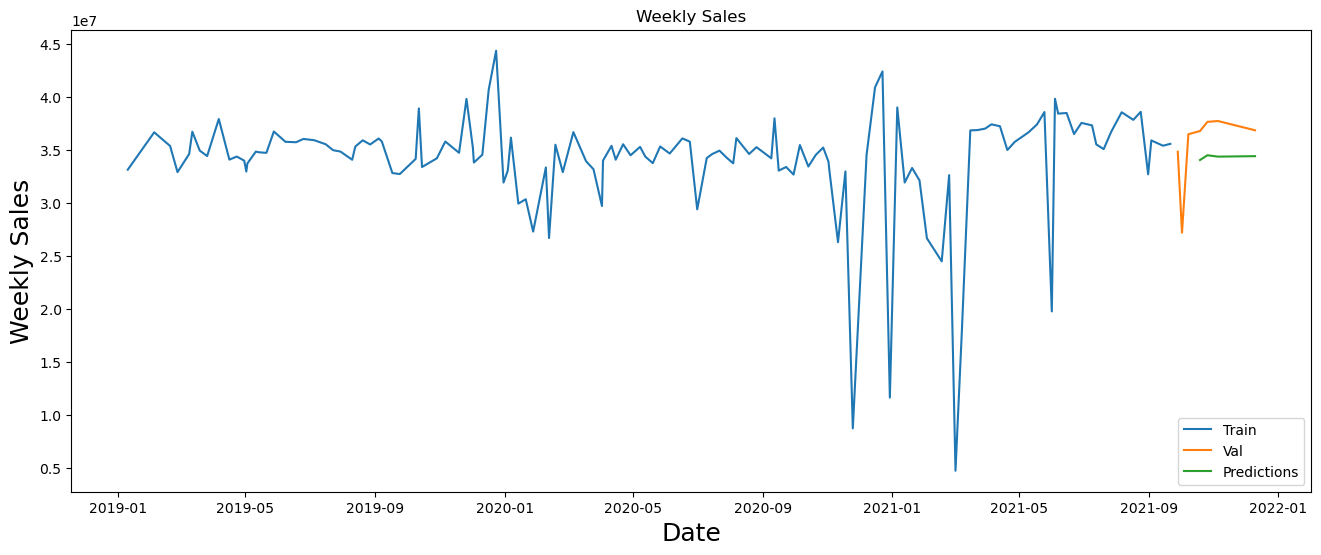

In [48]:
# 'train'
train = data[:training_data_len].copy()
train.index = pd.to_datetime(train.index)  # Convert index to datetime
valid_data = data[training_data_len:].copy().to_frame()
valid_data['Predictions'] = np.nan

# Fill in the predictions column with the predicted values
valid_data.iloc[-len(predictions):, valid_data.columns.get_loc('Predictions')] = predictions

# Visualize the data
plt.figure(figsize=(16, 6))
plt.title('Weekly Sales')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Weekly Sales', fontsize=18)
plt.plot(train.index, train.values, label='Train')
plt.plot(valid_data[['Weekly_Sales', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()
